# **PHÂN TÍCH KHÁM KHÁ DỮ LIỆU BỆNH TIỂU ĐƯỜNG**

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
from io import StringIO
from IPython import display


In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

## **Thống kê mô tả**

### **Hiển thị một số thông tin về dữ liệu**

In [3]:

# shape
print(f'+ Shape: {df.shape}')
# types
print(f'+ Data Types: \n{df.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(df.head(5))
display.display(df.tail(5))
# info
df.info()

+ Shape: (100000, 9)
+ Data Types: 
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
+ Contents: 


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB



### 1. Quy mô dữ liệu (Data Shape)
*   **Kích thước:** Tập dữ liệu bao gồm **100,000 dòng** (bản ghi/mẫu) và **9 cột** (đặc trưng/biến).
*   **Nhận xét:** Đây là một bộ dữ liệu có kích thước **lớn và đủ tốt** để huấn luyện các mô hình học máy (Machine Learning) như Logistic Regression, Decision Tree hay Random Forest mà không lo thiếu dữ liệu. Số lượng mẫu lớn giúp mô hình học được các quy luật tổng quát tốt hơn.

### 2. Chất lượng dữ liệu (Data Quality & Missing Values)
*   **Giá trị thiếu (Null values):**
    *   Cột `Non-Null Count` hiển thị con số **100000 non-null** cho tất cả 9 cột.
    *   **Nhận xét quan trọng:** Về mặt kỹ thuật, bộ dữ liệu này **SẠCH HOÀN TOÀN các giá trị rỗng (NaN)**. Bạn không cần thực hiện các bước xử lý `dropna()` hay điền khuyết thiếu (imputation) cho các giá trị Null.
    *   *Lưu ý:* Tuy không có NaN, vẫn cần kiểm tra xem có các giá trị "ẩn" đại diện cho việc thiếu dữ liệu hay không (ví dụ: trong cột `gender` có giá trị "Unknown" hay không, hoặc cột `smoking_history` có giá trị "No Info" hay không).

### 3. Kiểu dữ liệu (Data Types)
Dữ liệu bao gồm 3 loại định dạng chính, điều này gợi ý các bước tiền xử lý tiếp theo:

*   **Dữ liệu dạng chuỗi (Object) - Cần mã hóa (Encoding):**
    *   Gồm: `gender` (Giới tính), `smoking_history` (Lịch sử hút thuốc).
    *   **Hành động:** Máy tính không hiểu chữ, nên bắt buộc phải chuyển đổi các cột này sang dạng số (sử dụng **Label Encoding** hoặc **One-Hot Encoding**) trước khi đưa vào mô hình.

*   **Dữ liệu dạng số thực (Float64) - Biến liên tục:**
    *   Gồm: `age` (Tuổi), `bmi` (Chỉ số khối cơ thể), `HbA1c_level` (Chỉ số đường huyết trung bình).
    *   **Hành động:** Cần kiểm tra phân phối (distribution) và xem xét việc chuẩn hóa (Scaling) nếu dùng các thuật toán nhạy cảm với khoảng cách (như KNN, SVM, Logistic Regression). Cây quyết định (Decision Tree) thì không cần chuẩn hóa.

*   **Dữ liệu dạng số nguyên (Int64) - Biến rời rạc hoặc nhị phân:**
    *   Gồm: `hypertension` (Cao huyết áp), `heart_disease` (Bệnh tim), `blood_glucose_level` (Mức đường huyết), `diabetes` (Tiểu đường).
    *   **Phân tích kỹ hơn:**
        *   `hypertension`, `heart_disease`: Khả năng cao là biến nhị phân (0: Không, 1: Có).
        *   `blood_glucose_level`: Là biến định lượng rời rạc.
        *   `diabetes`: Đây chính là **Biến mục tiêu (Target Variable)** mà bạn cần dự đoán.


### **Kiểm tra tính toàn vẹn của dữ liệu**

In [4]:

# Kiểm tra giá trị null/nan
data_null = df[df.isnull().any(axis=1)]
if not data_null.empty:
    print('Số lượng dòng chứa giá trị null/nan: ', data_null.shape[0])
    display.display(data_null)
    print("Số lượng giá trị null/nan theo từng cột:")
    print(df.isnull().sum())
else:
    print('Không có giá trị null/nan nào.')

Không có giá trị null/nan nào.


In [5]:
data_dup = df[df.duplicated(keep=False)]
if not data_dup.empty:
    print('Số hàng trùng nhau: ', df.duplicated(keep="first").sum())

    # Nhóm theo toàn bộ các cột
    grouped = data_dup.groupby(list(df.columns))

    # Duyệt và hiển thị từng nhóm
    for i, (key, group) in enumerate(grouped, start=1):
        print(f'\n nhóm trùng lặp: {i} (số dòng: {len(group)})')
        display.display(group)

    print('Tổng hợp các dòng trùng lặp')
    display.display(data_dup)
else:
    print('Không có hàng nào trùng nhau.')

Số hàng trùng nhau:  3854

 nhóm trùng lặp: 1 (số dòng: 2)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
47708,Female,2.0,0,0,No Info,27.32,5.0,158,0
59468,Female,2.0,0,0,No Info,27.32,5.0,158,0



 nhóm trùng lặp: 2 (số dòng: 2)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
62073,Female,2.0,0,0,No Info,27.32,6.0,85,0
67439,Female,2.0,0,0,No Info,27.32,6.0,85,0



 nhóm trùng lặp: 3 (số dòng: 2)


...

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
1573,Male,80.0,1,0,No Info,27.32,3.5,126,0
43891,Male,80.0,1,0,No Info,27.32,3.5,126,0



 nhóm trùng lặp: 3085 (số dòng: 2)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
3817,Male,80.0,1,0,former,27.32,6.2,130,0
4224,Male,80.0,1,0,former,27.32,6.2,130,0


Tổng hợp các dòng trùng lặp


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
10,Female,53.0,0,0,never,27.32,6.1,85,0
14,Female,76.0,0,0,No Info,27.32,5.0,160,0
18,Female,42.0,0,0,No Info,27.32,5.7,80,0
41,Male,5.0,0,0,No Info,27.32,6.6,130,0
...,...,...,...,...,...,...,...,...,...
99980,Female,52.0,0,0,never,27.32,6.1,145,0
99985,Male,25.0,0,0,No Info,27.32,5.8,145,0
99989,Female,26.0,0,0,No Info,27.32,5.0,158,0
99990,Male,39.0,0,0,No Info,27.32,6.1,100,0


Biểu đồ tròn (Pie Chart) hoặc Cột (Bar Chart) - Tổng quan tỷ lệ

Cách đơn giản nhất để trả lời câu hỏi: "Dữ liệu của tôi 'bẩn' đến mức nào?"

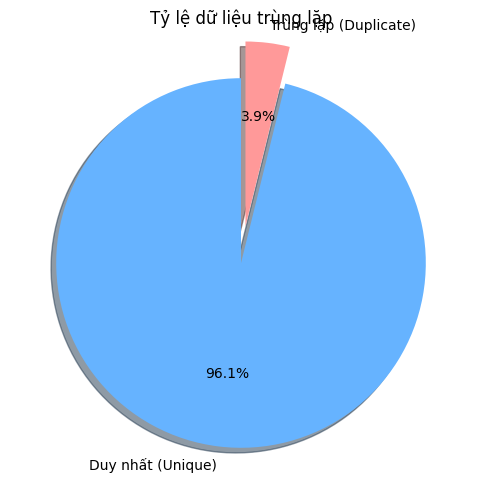

In [6]:
plt.figure(figsize=(6, 6))
dup_counts = df.duplicated().value_counts()

# Đổi tên index cho dễ hiểu
labels = ['Duy nhất (Unique)', 'Trùng lặp (Duplicate)']
colors = ['#66b3ff', '#ff9999']
explode = (0, 0.2)

plt.pie(dup_counts, explode=explode, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, shadow=True)
plt.title('Tỷ lệ dữ liệu trùng lặp')
plt.show()
plt.close()

Biểu đồ Histogram - Tần suất lặp lại

Cách này trả lời câu hỏi: "Một dòng dữ liệu bị lặp lại bao nhiêu lần? 2 lần, 3 lần hay 10 lần?"

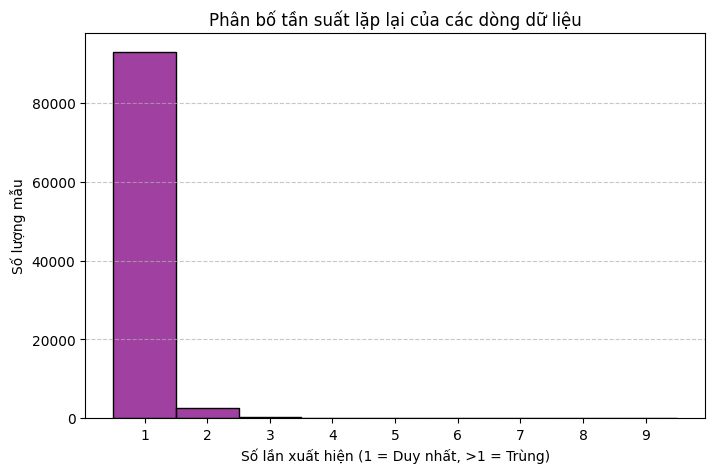

In [7]:
# Gom nhóm tất cả các cột và đếm size
# Lưu ý: Phải chuyển về string hoặc tuple nếu có dữ liệu list (nhưng titanic ok)
counts = df.groupby(df.columns.tolist(), as_index=False).size()

# counts['size'] chứa số lần xuất hiện của mỗi dòng
plt.figure(figsize=(8, 5))
sns.histplot(counts['size'], bins=np.arange(1, counts['size'].max() + 2) - 0.5, kde=False, color='purple')

plt.title('Phân bố tần suất lặp lại của các dòng dữ liệu')
plt.xlabel('Số lần xuất hiện (1 = Duy nhất, >1 = Trùng)')
plt.ylabel('Số lượng mẫu')
plt.xticks(range(1, counts['size'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
plt.close()


Heatmap - Vị trí trùng lặp (Cho dữ liệu nhỏ/trung bình)

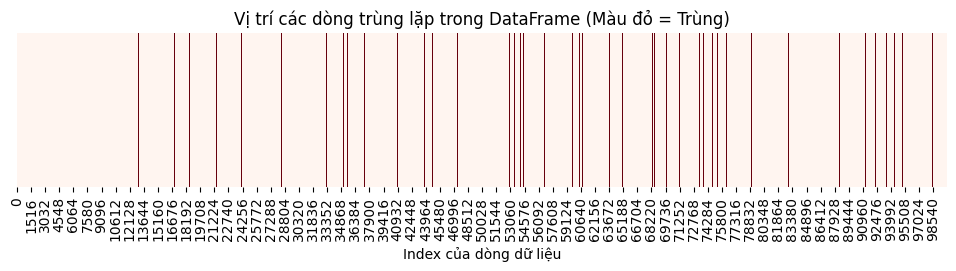

In [8]:
plt.figure(figsize=(12, 2))
# df.duplicated() trả về True/False. Ta chuyển thành 0/1 để vẽ
sns.heatmap(df.duplicated().to_frame().T, 
            cmap='Reds', cbar=False, yticklabels=False)

plt.title('Vị trí các dòng trùng lặp trong DataFrame (Màu đỏ = Trùng)')
plt.xlabel('Index của dòng dữ liệu')
plt.show()
plt.close()

### 1. Biểu đồ Tròn (Pie Chart) - Tỷ lệ tổng quan
*   **Thông số:**
    *   **Duy nhất (Unique):** Chiếm **96.1%** (tương đương khoảng 96,146 dòng).
    *   **Trùng lặp (Duplicate):** Chiếm **3.9%** (tương ứng với con số 3,854 dòng bạn đã nêu).
*   **Phân tích:**
    *   Tỷ lệ trùng lặp ~4% là một con số **đáng kể** nhưng không quá nghiêm trọng (dưới 5% thường được coi là chấp nhận được để xử lý nhanh).
    *   Tuy nhiên, trong bài toán y tế (dự đoán bệnh), việc giữ lại 4% dữ liệu trùng này có thể gây ra **Data Leakage** (rò rỉ dữ liệu) nếu bạn chia tập Train/Test ngẫu nhiên (một bản ghi nằm ở tập Train, bản sao của nó nằm ở Test, khiến kết quả Test cao ảo).

### 2. Biểu đồ Histogram (Cột tím) - Tần suất lặp lại
*   **Thông số:**
    *   Cột cao nhất (số 1): Đại diện cho các dòng chỉ xuất hiện 1 lần (dữ liệu sạch).
    *   Cột thấp thứ hai (số 2): Đại diện cho các dòng xuất hiện 2 lần (bị lặp 1 lần).
    *   Hầu như không có các cột ở số 3, 4, 5...
*   **Phân tích:**
    *   Dữ liệu chủ yếu bị **trùng đôi** (duplicate pairs). Tức là một bệnh nhân bị ghi nhận 2 lần.
    *   Không có hiện tượng một dòng bị lặp lại hàng chục hay hàng trăm lần (thường do lỗi vòng lặp code khi thu thập dữ liệu). Điều này cho thấy sự trùng lặp này có thể do tự nhiên (nhiều người có chỉ số giống hệt nhau) hoặc do lỗi nhập liệu thủ công đơn lẻ.

### 3. Biểu đồ Heatmap (Vạch đỏ) - Vị trí phân bố
*   **Thông số:**
    *   Trục hoành là Index (từ 0 đến 100,000).
    *   Các vạch đỏ đại diện cho vị trí xuất hiện của dòng trùng.
*   **Phân tích:**
    *   Các vạch đỏ **phân bố rải rác** trên toàn bộ tập dữ liệu, không tập trung cụ thể vào đầu hay cuối file.
    *   Điều này gợi ý rằng dữ liệu trùng lặp xuất hiện ngẫu nhiên trong quá trình thu thập, không phải do nối (concat) nhầm một file dữ liệu lớn vào một vị trí cụ thể.

---

### 4. Kết luận và Đề xuất Xử lý

**Nguyên nhân tiềm năng:**
Bộ dữ liệu này chỉ có 9 cột (Gender, Age, BMI, Glucose, v.v.). Với 100,000 người, xác suất để 2 người khác nhau có **hoàn toàn cùng** chỉ số (cùng tuổi, cùng giới tính, cùng BMI, cùng mức đường huyết...) là CÓ THỂ xảy ra.
*   *Ví dụ:* Có thể có nhiều phụ nữ, 50 tuổi, không hút thuốc, BMI 25.0, đường huyết 100.

**Tuy nhiên, hành động khuyến nghị là: XÓA BỎ (Drop).**

Tại sao nên xóa 3854 dòng này?
1.  **An toàn cho mô hình:** Thà xóa nhầm một vài người khác nhau (nhưng chỉ số giống hệt nhau) còn hơn để lại dữ liệu trùng làm mô hình bị thiên kiến (bias) và học thuộc lòng (overfitting).
2.  **Dữ liệu còn lại vẫn rất lớn:** Sau khi xóa, bạn vẫn còn hơn **96,000 dòng**, quá đủ để huấn luyện bất kỳ mô hình nào.

### **Các tính chất thống kê trên dữ liệu số**

In [9]:

description = df.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


### 1. Tổng quan về dữ liệu
*   **Count (Số lượng):** Tất cả các cột đều có 100,000 giá trị. Điều này cho thấy dữ liệu rất sạch, không có giá trị bị thiếu (missing values) ở các trường số này.

### 2. Phân tích chi tiết từng biến số

#### **Age (Tuổi)**
*   **Dải dữ liệu:** Từ 0.08 (khoảng 1 tháng tuổi) đến 80 tuổi. Dữ liệu bao phủ mọi lứa tuổi từ sơ sinh đến người cao tuổi.
*   **Trung bình (Mean):** ~41.89 tuổi.
*   **Trung vị (50%):** 43 tuổi.
*   **Nhận xét:** Giá trị trung bình và trung vị khá gần nhau (41.89 so với 43), cho thấy phân phối độ tuổi tương đối cân đối, không bị lệch quá nhiều. Độ lệch chuẩn (std) là 22.5, cho thấy độ tuổi của các đối tượng tham gia trải rộng khá lớn.

#### **Hypertension (Cao huyết áp) & Heart_disease (Bệnh tim)**
*   **Đặc điểm:** Đây là các biến phân loại dạng nhị phân (0 và 1), mặc dù được lưu dưới dạng số.
    *   0: Không mắc bệnh.
    *   1: Có mắc bệnh.
*   **Phân tích qua giá trị trung bình:**
    *   *Hypertension:* Mean = 0.07485 (tương đương **7.49%** mẫu bị cao huyết áp).
    *   *Heart_disease:* Mean = 0.03942 (tương đương **3.94%** mẫu bị bệnh tim).
*   **Phân vị (25%, 50%, 75%):** Đều bằng 0. Điều này hợp lý vì tỷ lệ người mắc bệnh rất thấp (nhóm thiểu số).

#### **BMI (Chỉ số khối cơ thể)**
*   **Trung bình:** ~27.32.
*   **Trung vị:** 27.32.
*   **Nhận xét:**
    *   Giá trị trung bình và trung vị gần như trùng khớp tuyệt đối, gợi ý phân phối chuẩn (hình chuông).
    *   Tuy nhiên, **Max = 95.69** là một con số rất lớn (béo phì cực độ), trong khi **Min = 10.01** (thiếu cân nặng).
    *   Với mức trung bình ~27.3, phần lớn mẫu khảo sát nằm trong nhóm "Thừa cân" (Overweight, thường tính từ BMI > 25).

#### **HbA1c_level (Chỉ số Hemoglobin A1c)**
*   *Đây là chỉ số xét nghiệm lượng đường trong máu trung bình trong 2-3 tháng qua.*
*   **Trung bình:** ~5.53.
*   **Dải dữ liệu:** 3.5 đến 9.0.
*   **Phân tích:**
    *   Mức bình thường thường dưới 5.7%.
    *   Giá trị 75% là 6.2 và Max là 9.0 cho thấy có một nhóm đáng kể bệnh nhân có nguy cơ hoặc đã mắc tiểu đường (mức > 6.5% thường chẩn đoán tiểu đường).

#### **Blood_glucose_level (Đường huyết)**
*   **Trung bình:** ~138.06 mg/dL.
*   **Độ lệch chuẩn (Std):** 40.7.
*   **Phân vị:**
    *   50% (Trung vị): 140.
    *   75%: 159.
    *   Max: 300.
*   **Nhận xét:** Dữ liệu biến động khá mạnh. Giá trị Max lên tới 300 là mức đường huyết rất cao, nguy hiểm.

#### **Diabetes (Tiểu đường - Biến mục tiêu)**
*   **Đặc điểm:** Biến nhị phân (0: Không bị, 1: Bị tiểu đường).
*   **Trung bình:** 0.085.
*   **Kết luận:** Khoảng **8.5%** số người trong tập dữ liệu này mắc bệnh tiểu đường. Đây là một tập dữ liệu **mất cân bằng (imbalanced dataset)**, vì số lượng người không bị bệnh (91.5%) áp đảo số người bị bệnh.

### Tóm tắt các điểm quan trọng (Key Insights):
1.  **Dữ liệu mất cân bằng:** Tỷ lệ người bị tiểu đường, tim mạch, cao huyết áp đều thấp (<10%). Khi xây dựng mô hình máy học (Machine Learning), bạn cần lưu ý xử lý vấn đề mất cân bằng dữ liệu.
2.  **Nguy cơ sức khỏe:** Mẫu dữ liệu có xu hướng thừa cân (BMI trung bình > 27).
3.  **Ngoại lai (Outliers):** Cần chú ý kỹ cột BMI (max 95.69) xem đây là số liệu thực tế hay nhiễu. Tuy nhiên, trong y tế, các chỉ số cực đoan này vẫn có thể xảy ra.
4.  **Chất lượng dữ liệu:** Rất tốt vì không có giá trị null (count = 100,000 ở mọi cột).

### **Các tính chất thống kê trên dữ liệu phân loại**

In [10]:
df.describe(include=['O'])


,gender,smoking_history
count,100000,100000
unique,3,6
top,Female,No Info
freq,58552,35816



### 1. Giải thích các chỉ số thống kê

*   **count (Số lượng):** Tổng số dòng dữ liệu không bị trống (non-null).
*   **unique (Số giá trị duy nhất):** Số lượng các nhóm hoặc phân loại khác nhau có trong cột đó.
*   **top (Giá trị phổ biến nhất):** Giá trị xuất hiện nhiều nhất trong cột (Mode).
*   **freq (Tần suất của top):** Số lần xuất hiện của giá trị phổ biến nhất đó.

---

### 2. Phân tích chi tiết từng biến

#### **Biến `gender` (Giới tính)**
*   **count:** 100,000 (Dữ liệu đầy đủ, không thiếu).
*   **unique:** 3.
    *   *Phân tích:* Thông thường giới tính là 2 (Male/Female). Việc có **3 giá trị** cho thấy dữ liệu có thể chứa một giá trị thứ ba như "Other" (Khác) hoặc "Unknown" (Không xác định). Khi xử lý dữ liệu, bạn cần kiểm tra xem nhóm thứ 3 này chiếm tỷ lệ bao nhiêu; nếu quá ít, có thể cân nhắc loại bỏ hoặc gộp nhóm.
*   **top:** "Female" (Nữ).
*   **freq:** 58,552.
    *   *Phân tích:* Nữ giới chiếm đa số trong tập dữ liệu này, với tỷ lệ khoảng **58.55%** (58,552 / 100,000). Điều này cho thấy mẫu dữ liệu hơi lệch về phía nữ giới, nhưng không quá nghiêm trọng.

#### **Biến `smoking_history` (Lịch sử hút thuốc)**
*   **count:** 100,000 (Dữ liệu đầy đủ).
*   **unique:** 6.
    *   *Phân tích:* Có tới **6 trạng thái** khác nhau về lịch sử hút thuốc. Các giá trị này thường là: *never (chưa từng), current (đang hút), former (đã cai), ever (đã từng), not current (không hút hiện tại), No Info (không có thông tin)*...
*   **top:** "No Info".
*   **freq:** 35,816.
    *   *Phân tích:* Đây là một vấn đề quan trọng. Giá trị xuất hiện nhiều nhất lại là "No Info", chiếm tới **35.82%** (35,816 / 100,000).
    *   **Ý nghĩa thực tế:** Hơn 1/3 số người tham gia không có thông tin rõ ràng về việc hút thuốc. Trong các bài toán máy học (Machine Learning), "No Info" có thể được coi là một loại giá trị thiếu (missing value) dạng ẩn, hoặc phải được xử lý như một nhóm riêng biệt (category riêng) vì bản thân việc "không khai báo" cũng có thể mang một ý nghĩa thống kê nào đó.

### Tóm tắt và Khuyến nghị (Key Takeaways)

1.  **Về Giới tính:** Cần kiểm tra giá trị thứ 3 trong `gender` là gì và số lượng bao nhiêu. Nếu số lượng rất nhỏ (ví dụ: vài chục người), nó có thể là nhiễu.
2.  **Về Lịch sử hút thuốc:** Dữ liệu về hút thuốc có độ tin cậy thấp hơn do nhóm "No Info" chiếm tỷ trọng lớn nhất (gần 36%). Khi xây dựng mô hình dự đoán bệnh (như tiểu đường), việc xử lý nhóm "No Info" này sẽ ảnh hưởng lớn đến độ chính xác của mô hình. Không nên xóa 35% dữ liệu này mà nên giữ nó như một phân loại riêng biệt.
3.  **Tính đầy đủ:** Cả hai cột đều có đủ 100,000 dòng, không có giá trị `null` kỹ thuật (NaN), giúp giảm bớt công đoạn xử lý dữ liệu trống cơ bản.

### **Tần số xuất hiện của các lớp trong biến mục tiêu**

In [11]:
df["diabetes"].value_counts()


diabetes
0    91500
1     8500
Name: count, dtype: int64

### 1. Thông tin từ dữ liệu
*   **Tổng số mẫu:** 100,000 bản ghi (91,500 + 8,500).
*   **Lớp 0 (Không bị tiểu đường):** 91,500 mẫu.
*   **Lớp 1 (Bị tiểu đường):** 8,500 mẫu.

### 2. Phân tích tỷ lệ
*   **Tỷ lệ lớp 0:** $\frac{91,500}{100,000} = 91.5\%$
*   **Tỷ lệ lớp 1:** $\frac{8,500}{100,000} = 8.5\%$
*   **Tỷ lệ chênh lệch (Ratio):** Lớp đa số (0) gấp khoảng **10.7 lần** lớp thiểu số (1).

### 3. Nhận định quan trọng: Mất cân bằng dữ liệu (Imbalanced Data)
Đây là một ví dụ điển hình của bài toán **mất cân bằng dữ liệu**. Sự chênh lệch lớn giữa hai lớp (91.5% vs 8.5%) sẽ gây ra các vấn đề sau nếu không được xử lý:

*   **Mô hình thiên vị (Bias):** Mô hình máy học sẽ có xu hướng dự đoán tất cả mọi người đều "Không bị bệnh" (Lớp 0). Nếu mô hình làm như vậy, độ chính xác (Accuracy) vẫn đạt tới **91.5%**, nhưng nó hoàn toàn thất bại trong việc phát hiện người bệnh (Lớp 1) - mục tiêu chính của bài toán y tế.
*   **Độ đo Accuracy trở nên vô nghĩa:** Bạn không thể dùng độ chính xác (Accuracy) làm thước đo chính. Thay vào đó, cần tập trung vào các chỉ số như **Recall (Độ nhạy)**, **Precision**, **F1-Score**, hoặc **AUC-ROC**.

### 4. Khuyến nghị xử lý
Để xây dựng mô hình dự đoán tốt trên tập dữ liệu này, cân nhắc các phương pháp sau:

1.  **Kỹ thuật lấy mẫu (Resampling):**
    *   *Undersampling:* Giảm bớt mẫu của lớp 0 (tuy nhiên có thể làm mất thông tin).
    *   *Oversampling:* Nhân bản mẫu của lớp 1.
    *   *SMOTE (Synthetic Minority Over-sampling Technique):* Tạo ra các dữ liệu giả lập mới cho lớp 1 dựa trên các mẫu lân cận.
2.  **Điều chỉnh trọng số (Class Weights):** Khi huấn luyện mô hình (như Logistic Regression, Random Forest, hay Neural Networks), hãy gán trọng số cao hơn cho Lớp 1 (ví dụ: trọng số 10:1) để mô hình "coi trọng" việc dự đoán đúng người bệnh hơn là người khỏe mạnh.
3.  **Lựa chọn mô hình:** Sử dụng các mô hình mạnh với dữ liệu mất cân bằng như XGBoost, LightGBM hoặc CatBoost (thường tích hợp sẵn tham số `scale_pos_weight` để xử lý vấn đề này).

### **Mối tương quan giữa các tính chất (Correlations)**

In [12]:

corr = df.select_dtypes(include=['number']).corr(method='pearson')
display.display(corr)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.251171,0.233354,0.337396,0.101354,0.110672,0.258008
hypertension,0.251171,1.000000,0.121262,0.147666,0.080939,0.084429,0.197823
heart_disease,0.233354,0.121262,1.000000,0.061198,0.067589,0.070066,0.171727
bmi,0.337396,0.147666,0.061198,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.101354,0.080939,0.067589,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.110672,0.084429,0.070066,0.091261,0.166733,1.000000,0.419558
diabetes,0.258008,0.197823,0.171727,0.214357,0.400660,0.419558,1.000000



Ma trận này sử dụng hệ số tương quan Pearson, giá trị nằm từ **-1 đến 1**.
*   Giá trị càng gần **1**: Tương quan thuận (biến này tăng thì biến kia tăng).
*   Giá trị càng gần **-1**: Tương quan nghịch (biến này tăng thì biến kia giảm).
*   Giá trị gần **0**: Ít hoặc không có mối liên hệ tuyến tính.

---

### 1. Tương quan với biến mục tiêu `diabetes` (Tiểu đường)
Đây là phần quan trọng nhất để xác định yếu tố nào ảnh hưởng mạnh nhất đến khả năng mắc bệnh.

*   **`blood_glucose_level` (0.4196) & `HbA1c_level` (0.4007):**
    *   **Phân tích:** Đây là hai yếu tố có mối tương quan **mạnh nhất** với bệnh tiểu đường. Điều này hoàn toàn hợp lý về mặt y học, vì mức đường huyết và chỉ số HbA1c là các tiêu chuẩn vàng để chẩn đoán tiểu đường.
    *   **Ý nghĩa:** Khi đường huyết hoặc HbA1c tăng, khả năng mắc tiểu đường tăng lên rất rõ rệt. Đây sẽ là những "feature" (đặc trưng) quan trọng nhất cho mô hình dự đoán.

*   **`age` (0.2580):**
    *   **Phân tích:** Tương quan dương mức độ trung bình.
    *   **Ý nghĩa:** Tuổi càng cao, nguy cơ mắc tiểu đường càng lớn.

*   **`bmi` (0.2144):**
    *   **Phân tích:** Có mối liên hệ dương.
    *   **Ý nghĩa:** Chỉ số khối cơ thể (BMI) cao (thừa cân, béo phì) đi kèm với nguy cơ tiểu đường cao hơn.

*   **`hypertension` (0.1978) & `heart_disease` (0.1717):**
    *   **Phân tích:** Tương quan dương nhưng yếu hơn các chỉ số xét nghiệm máu. Tuy nhiên, nó vẫn cho thấy người có bệnh nền (huyết áp cao, tim mạch) có xu hướng mắc tiểu đường cao hơn người bình thường.

### 2. Tương quan giữa các biến độc lập (Đa cộng tuyến)
Việc xem xét tương quan giữa các biến đầu vào giúp phát hiện hiện tượng đa cộng tuyến (multicollinearity) - khi hai biến quá giống nhau có thể gây nhiễu cho một số mô hình hồi quy.

*   **`age` và `bmi` (0.3374):**
    *   Có mối liên hệ tương đối: Người lớn tuổi trong tập dữ liệu này có xu hướng có BMI cao hơn.
*   **`age` và `hypertension` (0.2512) / `heart_disease` (0.2334):**
    *   Tuổi tác đi kèm với nguy cơ cao huyết áp và bệnh tim. Điều này rất logic theo quy luật lão hóa tự nhiên.
*   **`HbA1c_level` và `blood_glucose_level` (0.1667):**
    *   **Điều bất ngờ:** Mặc dù cả hai đều đo lường liên quan đến đường trong máu, nhưng hệ số tương quan giữa chúng lại khá thấp (chỉ 0.16).
    *   **Lý giải:** `blood_glucose_level` là đường huyết tại thời điểm đo (có thể dao động nhanh), còn `HbA1c` là đường huyết trung bình trong 2-3 tháng. Việc chúng không tương quan quá chặt chẽ (ví dụ > 0.8) là **tin tốt cho mô hình**, vì nghĩa là mỗi biến cung cấp một khía cạnh thông tin riêng biệt, không bị trùng lặp.

### Tóm tắt (Key Insights)

1.  **Các chỉ báo vàng (Top Predictors):** `blood_glucose_level` và `HbA1c_level` là hai yếu tố dự báo mạnh nhất. Bất kỳ mô hình nào cũng sẽ dựa rất nhiều vào hai chỉ số này.
2.  **Yếu tố nhân khẩu học:** `age` và `bmi` đóng vai trò quan trọng thứ cấp.
3.  **Không có đa cộng tuyến nghiêm trọng:** Không có cặp biến độc lập nào có tương quan quá cao (ví dụ > 0.7). Điều này rất tốt, cho phép bạn sử dụng hầu hết các biến này vào mô hình (như Hồi quy Logistic) mà không cần lo lắng nhiều về việc loại bỏ bớt biến trùng lặp.

## **Trực quan hóa dữ liệu**

### **Hiển thị trên từng tính chất đơn (Univariate Plots)**

Box and whisker plots

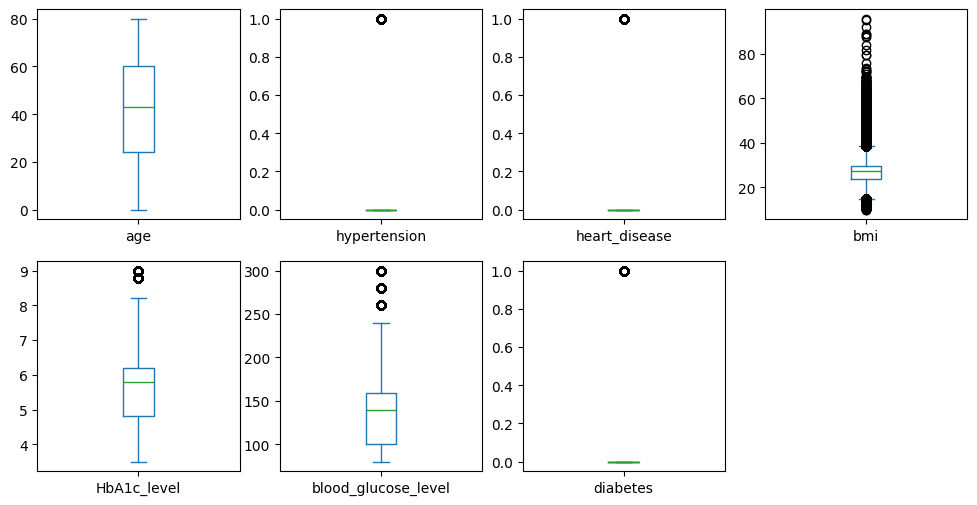

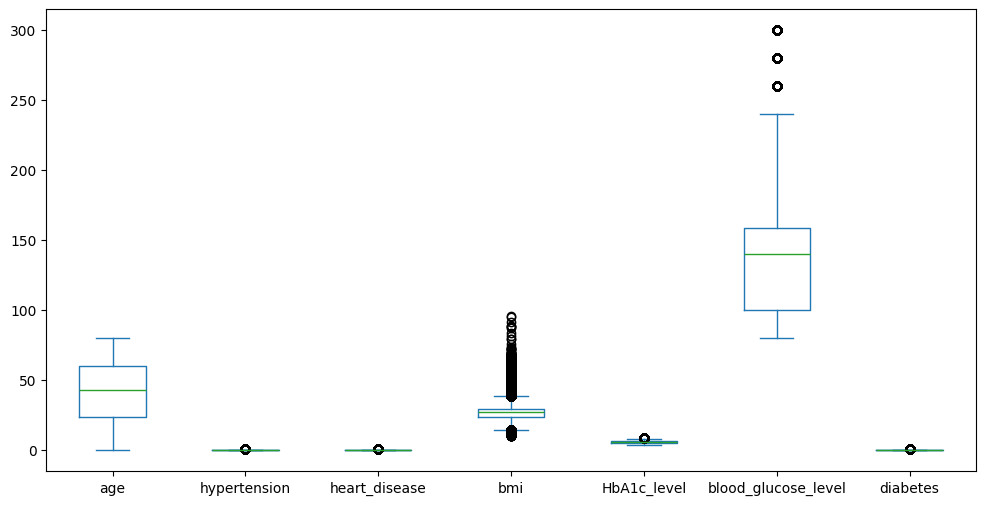

In [13]:
df.plot(kind="box", subplots=True, layout=(2, 4), sharex=False, sharey=False, figsize=(12,6))
df.plot(kind="box", figsize=(12,6))
plt.show()
plt.close()


### 1. Tổng quan về biểu đồ
Đây là các biểu đồ hộp (Box Plots), một công cụ thống kê rất mạnh để trực quan hóa sự phân tán của dữ liệu.
*   **Hộp chữ nhật (The Box):** Biểu thị khoảng tứ phân vị (IQR - Interquartile Range), chứa 50% dữ liệu ở giữa (từ phân vị 25% đến 75%).
*   **Đường màu xanh lá ở giữa hộp:** Biểu thị giá trị trung vị (Median - 50%).
*   **Hai râu (Whiskers):** Kéo dài ra ngoài hộp để biểu thị độ biến thiên bên ngoài 50% ở giữa.
*   **Các vòng tròn đen (Points):** Biểu thị các giá trị ngoại lai (Outliers) - những giá trị nằm quá xa so với phần còn lại của dữ liệu.

---

### 2. Phân tích từng biến số

#### **Biến `age` (Tuổi)**
*   **Phân phối:** Hộp khá dài và cân đối, râu kéo dài từ 0 đến 80.
*   **Nhận xét:** Dữ liệu tuổi trải đều, không có giá trị ngoại lai (outliers). Điều này cho thấy mẫu dữ liệu bao phủ tốt mọi nhóm tuổi.

#### **Biến `hypertension`, `heart_disease`, `diabetes`**
*   **Đặc điểm chung:** Đây là các biến nhị phân (chỉ có 0 và 1).
*   **Hình dáng:** Hộp bị "bẹp" xuống đáy (giá trị 0) vì đại đa số mẫu là người khỏe mạnh (giá trị 0). Chỉ có một số ít giá trị 1 hiện lên dưới dạng các điểm ngoại lai (vòng tròn đen phía trên).
*   **Kết luận:** Biểu đồ hộp không phải là cách tốt nhất để hiển thị biến nhị phân, nhưng nó xác nhận lại sự **mất cân bằng dữ liệu** nghiêm trọng (số lượng số 1 quá ít so với số 0).

#### **Biến `bmi` (Chỉ số khối cơ thể)**
*   **Phân phối:** Hộp rất hẹp nằm ở khoảng 20-30.
*   **Ngoại lai (Outliers):** Một lượng khổng lồ các chấm đen xuất hiện phía trên hộp, kéo dài lên tận gần 100.
*   **Phân tích:** Dữ liệu có rất nhiều người bị béo phì nặng (BMI cực cao). Những giá trị này là ngoại lai về mặt thống kê nhưng có thể là tín hiệu rất quan trọng trong y tế (người béo phì có nguy cơ bệnh cao).

#### **Biến `HbA1c_level` (Chỉ số đường huyết trung bình)**
*   **Phân phối:** Khá tập trung, nhưng bắt đầu xuất hiện ngoại lai ở phía trên (giá trị > 8.0).
*   **Ý nghĩa:** Phần lớn mọi người có chỉ số bình thường, nhưng nhóm "ngoại lai" phía trên chính là nhóm có nguy cơ hoặc đã mắc tiểu đường.

#### **Biến `blood_glucose_level` (Đường huyết)**
*   **Phân phối:** Tương tự HbA1c nhưng khoảng biến thiên rộng hơn nhiều.
*   **Ngoại lai:** Có một nhóm tách biệt hẳn lên phía trên (giá trị 250-300).
*   **Ý nghĩa:** Sự tách biệt này rất đáng chú ý. Có thể đây là nhóm bệnh nhân tiểu đường nặng, tách biệt hẳn so với quần thể người bình thường.

---

### 3. So sánh độ biến thiên
Hình 6 gộp chung các biểu đồ lại trên cùng một trục tung (trục Y) để so sánh độ lớn giá trị.

*   **Vấn đề về tỷ lệ (Scale):**
    *   Biến `blood_glucose_level` có giá trị rất lớn (lên tới 300), làm cho các biến khác như `HbA1c` (tầm 5-9) hay các biến nhị phân (0-1) trở nên quá bé nhỏ, gần như không nhìn thấy được.
    *   Biến `bmi` cũng bị nén lại do thang đo lớn của đường huyết.

### 4. Kết luận và Khuyến nghị

1.  **Xử lý ngoại lai (Outliers):** Biến `bmi`, `HbA1c_level`, và `blood_glucose_level` có rất nhiều ngoại lai phía trên.
    *   *Không nên xóa vội:* Trong y tế, những giá trị cao bất thường này thường chính là những người bị bệnh (Positive cases). Xóa chúng có thể làm mất đi những mẫu quan trọng nhất để mô hình học được cách phát hiện bệnh.
    *   *Kiểm tra tính hợp lý:* Chỉ xóa nếu giá trị đó phi lý (ví dụ: BMI > 100 hoặc tuổi < 0).

2.  **Chuẩn hóa dữ liệu (Normalization/Scaling):**
    *   Do thang đo các biến quá khác biệt (Tuổi: 0-80, Đường huyết: 80-300, BMI: 10-95, HbA1c: 3-9), bạn **bắt buộc** phải chuẩn hóa dữ liệu (dùng Min-Max Scaler hoặc Standard Scaler) trước khi đưa vào các mô hình máy học (đặc biệt là KNN, SVM, Neural Networks) để tránh việc mô hình bị lệch hướng bởi các biến có giá trị lớn như `blood_glucose_level`.

Histogram chart

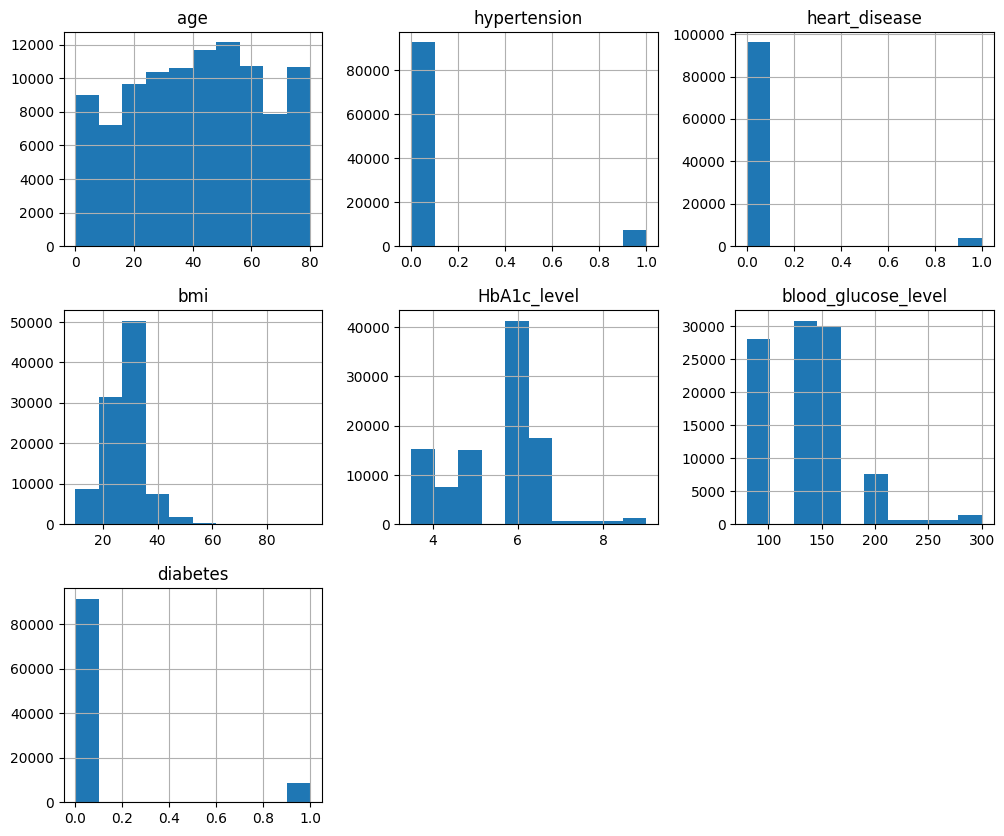

In [14]:
numeric_cols = df.select_dtypes(include='number')
numeric_cols.hist(figsize=(12,10))
plt.show()
plt.close()


### 1. Biểu đồ `age` (Tuổi)
*   **Hình dạng:** Phân phối khá đồng đều, gần giống hình chữ nhật nhưng có chút biến động. Không có đỉnh nhọn (peak) quá rõ rệt.
*   **Phân tích:**
    *   Dữ liệu bao phủ đều các nhóm tuổi từ trẻ em (0-10) đến người già (70-80).
    *   Nhóm 80 tuổi có vẻ cao đột biến ở cột cuối cùng, có thể do việc gộp tất cả những người >80 tuổi vào nhóm này (truncation/clipping).
    *   **Ý nghĩa:** Tập dữ liệu này rất tốt vì đại diện cho mọi lứa tuổi, không bị thiên lệch về một nhóm tuổi cụ thể nào.

### 2. Các biến phân loại nhị phân (`hypertension`, `heart_disease`, `diabetes`)
*   **Hình dạng:** Cả 3 biểu đồ đều có hình dáng cực kỳ lệch (skewed). Cột bên trái (giá trị 0 - Không bệnh) cao áp đảo so với cột bên phải (giá trị 1 - Có bệnh).
*   **Phân tích:**
    *   **`hypertension` (Cao huyết áp):** Số người không bị bệnh chiếm đa số, nhưng số người bị bệnh (cột nhỏ bên phải) vẫn nhìn thấy được.
    *   **`heart_disease` (Bệnh tim):** Số người bị bệnh rất ít (cột bên phải rất thấp).
    *   **`diabetes` (Tiểu đường):** Tương tự, đây là biến mục tiêu. Sự chênh lệch lớn này xác nhận lại vấn đề **mất cân bằng dữ liệu (Imbalanced Dataset)** nghiêm trọng.
*   **Ý nghĩa:** Khi huấn luyện mô hình, nếu không xử lý, máy tính sẽ học rất giỏi các đặc điểm của người "Khỏe mạnh" (vì mẫu quá nhiều) nhưng lại rất kém trong việc nhận diện người "Có bệnh".

### 3. Biểu đồ `bmi` (Chỉ số khối cơ thể)
*   **Hình dạng:** Phân phối lệch phải (Right-skewed) rõ rệt. Đỉnh (Mode) nằm ở khoảng 25-30.
*   **Phân tích:**
    *   Phần lớn dữ liệu tập trung ở mức 20-35 (Bình thường đến Thừa cân/Béo phì độ 1).
    *   Cái đuôi dài kéo về phía bên phải (các giá trị > 40, 50...) cho thấy có một số lượng đáng kể người bị béo phì nặng đến rất nặng.
    *   **Ý nghĩa:** Đây là phân phối thực tế hợp lý trong y tế. Các giá trị ở đuôi bên phải tuy ít nhưng có thể liên quan mật thiết đến bệnh tiểu đường.

### 4. Biểu đồ `HbA1c_level` (Chỉ số đường huyết trung bình)
*   **Hình dạng:** Không tuân theo phân phối chuẩn (không hình chuông). Có hai cụm cột cao nổi bật.
*   **Phân tích:**
    *   **Cụm 1 (khoảng 5.0 - 6.0):** Đây là nhóm đa số, chỉ số HbA1c ở mức bình thường.
    *   **Cụm 2 (khoảng 6.0 - 7.0):** Nhóm tiền tiểu đường hoặc tiểu đường nhẹ.
    *   Có một khoảng trống nhỏ và sau đó là một số lượng ít các giá trị > 8.0, 9.0 (nhóm tiểu đường nặng).
*   **Ý nghĩa:** Dữ liệu có tính phân cụm (clustering). Điểm cắt (threshold) chẩn đoán bệnh thường nằm ở khoảng 6.5, và biểu đồ phản ánh khá rõ sự phân chia này.

### 5. Biểu đồ `blood_glucose_level` (Đường huyết)
*   **Hình dạng:** Phân phối đa đỉnh (Multimodal distribution).
*   **Phân tích:**
    *   **Đỉnh 1 (lớn nhất):** Tập trung ở khoảng 80-160. Đây là mức đường huyết của người bình thường hoặc hơi cao.
    *   **Đỉnh 2 (nhỏ hơn):** Một nhóm tách biệt ở khoảng 200.
    *   **Đỉnh 3 (rất nhỏ):** Nhóm ở mức 280-300.
*   **Ý nghĩa:** Biểu đồ này cực kỳ thú vị. Nó cho thấy quần thể dân số trong dữ liệu phân tách rõ ràng thành các nhóm: Nhóm khỏe mạnh và Nhóm bệnh lý. Khoảng trống giữa mức 160 và 200 cho thấy sự phân hóa rõ rệt giữa người bình thường và người bệnh, giúp mô hình máy học dễ dàng tìm ra ranh giới phân loại (decision boundary).

### Tóm tắt chung
1.  **Dữ liệu sạch:** Không thấy các giá trị nhiễu vô lý (ví dụ tuổi âm, BMI = 0).
2.  **Mất cân bằng:** Các biến bệnh lý (`diabetes`, `heart_disease`) bị mất cân bằng nặng.
3.  **Phân hóa rõ ràng:** Các biến chỉ số xét nghiệm (`HbA1c`, `blood_glucose`) có sự phân nhóm tự nhiên, rất thuận lợi cho việc phân loại bệnh.

Biểu đồ mật độ Density

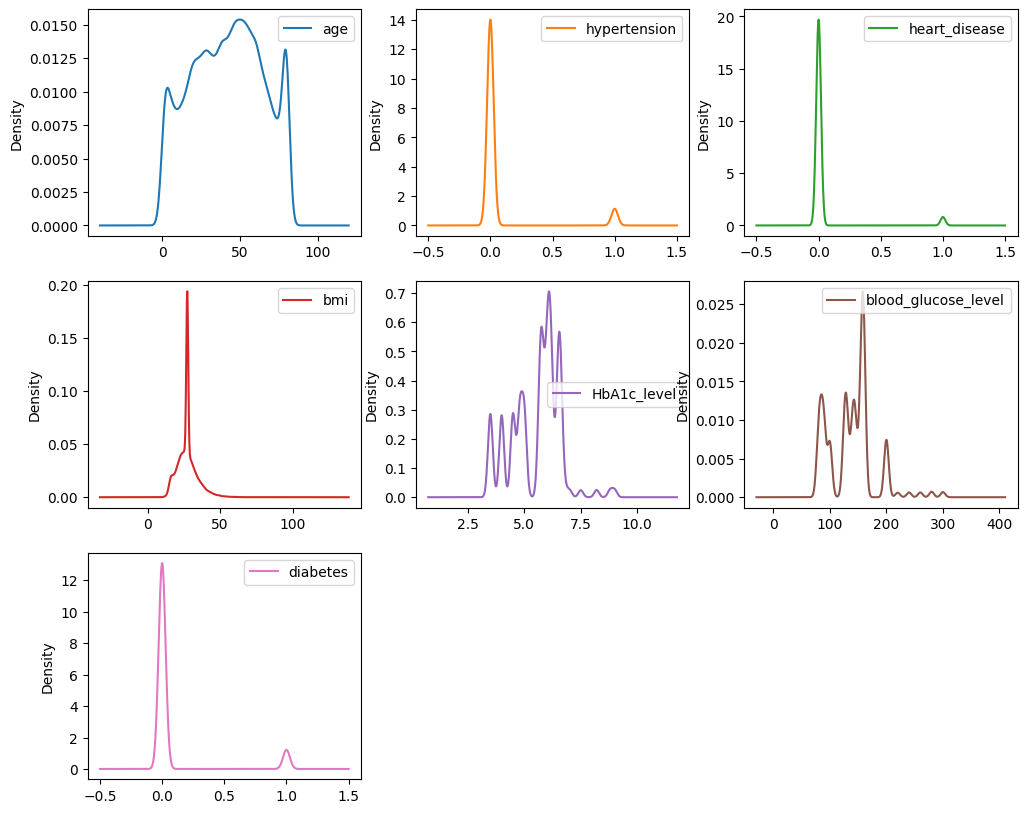

In [15]:
df.select_dtypes(include='number').plot(
    kind='density', subplots=True, layout=(3,3), sharex=False, figsize=(12,10)
)
plt.show()
plt.close()

Trực quan từ biểu đồ histogram

### **Hiển thị nhiều tính chất (Multivariate Plots)**

Scatter Matrix (Ma trận phân tán)

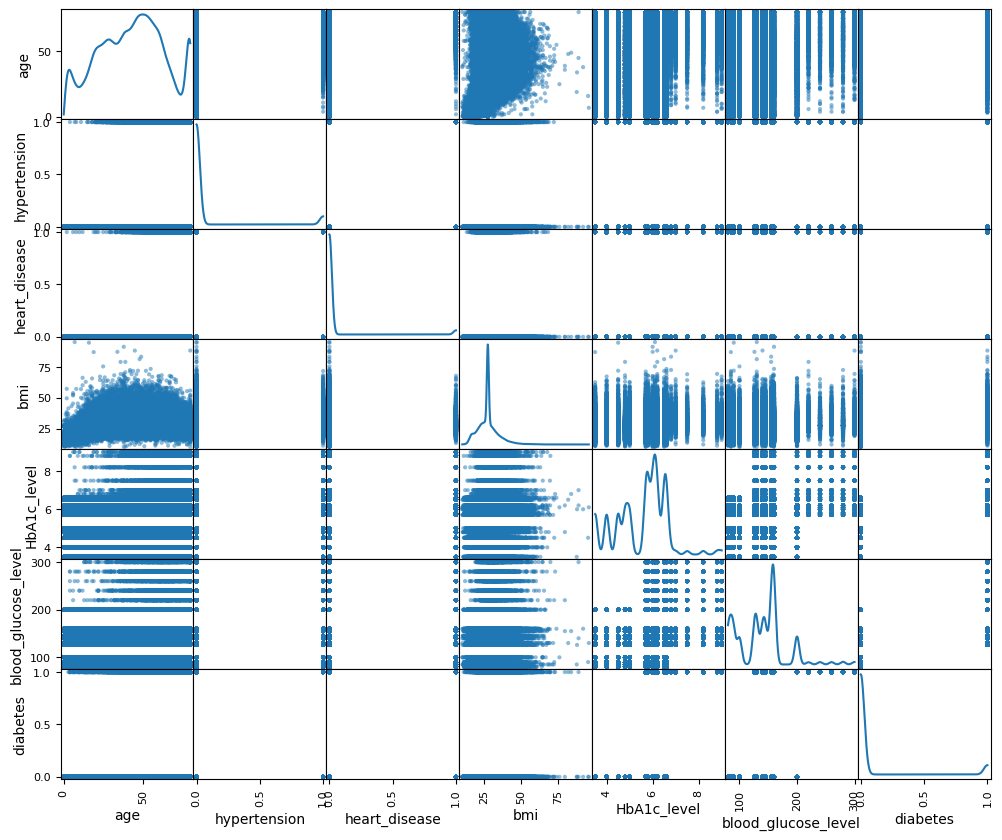

In [16]:
numeric_cols = df.select_dtypes(include='number')
pd.plotting.scatter_matrix(numeric_cols, figsize=(12,10), diagonal='kde')
plt.show()
plt.close()

Hiển thị mối tương quan giữa các biến với nhau bằng biểu đồ heatmap

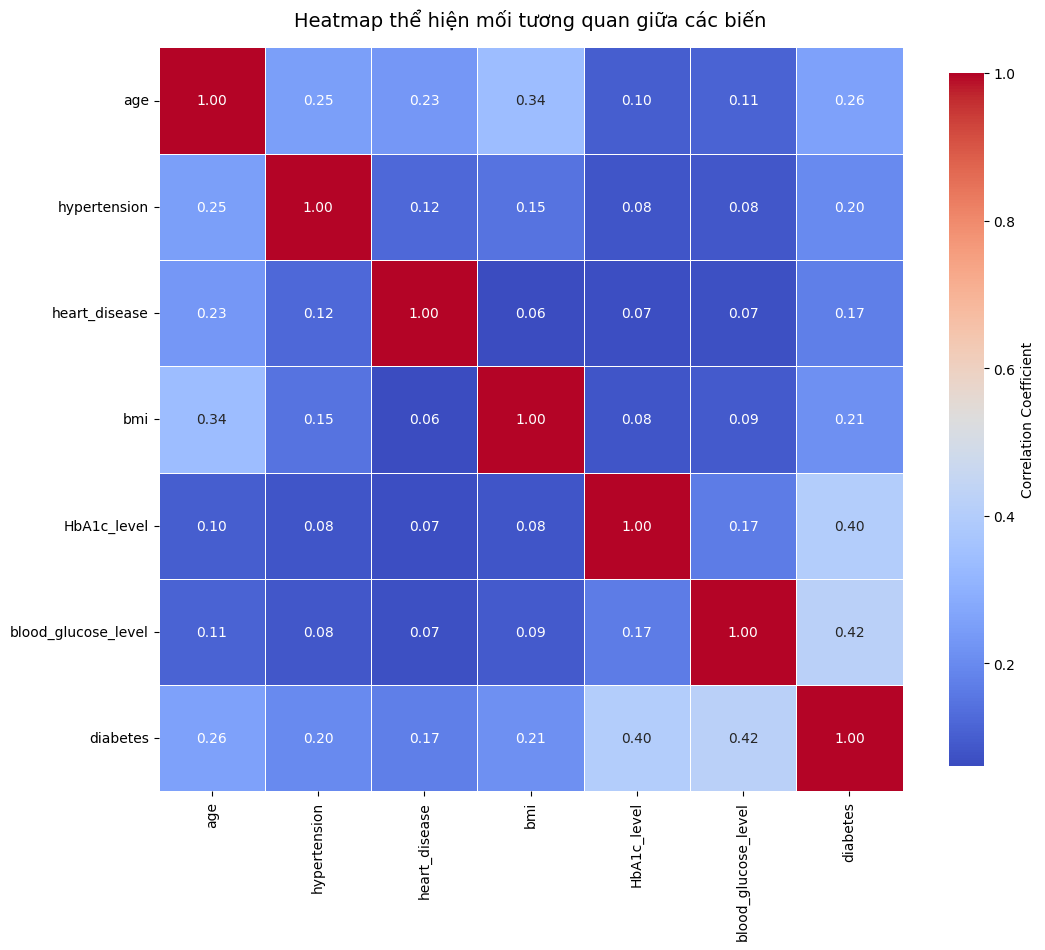

In [17]:
plt.figure(figsize=(12,12))
sns.heatmap(
    corr,
    annot=True, #hien thi gtri tren cac o
    fmt = ".2f", #lam tron 2 chu so thap phan
    cmap = "coolwarm", #bang mau 
    linewidths=0.5, #khoang cach giua cac o
    square=True, # hien thi o vuong cho dep
    cbar_kws={"shrink": 0.75, "label": "Correlation Coefficient"} #thanh mau ben phai
)
plt.title("Heatmap thể hiện mối tương quan giữa các biến", fontsize = 14, pad=15)
plt.show()
plt.close()


### 1. Biểu đồ Scatter Matrix (Ma trận phân tán)

Đây là biểu đồ phức tạp nhất nhưng chứa đựng nhiều thông tin nhất. Nó vẽ ghép cặp từng biến với nhau.
*   **Đường chéo chính (Diagonal):** Là biểu đồ mật độ (Density Plot) của từng biến riêng lẻ.
*   **Các ô còn lại:** Là biểu đồ phân tán (Scatter Plot) giữa biến hàng và biến cột.

**Phân tích chi tiết:**

*   **Hàng cuối cùng (Biến mục tiêu `diabetes`):**
    *   Đây là phần quan trọng nhất. Hãy nhìn vào hàng ngang cuối cùng (hoặc cột dọc cuối cùng).
    *   **`diabetes` vs `blood_glucose_level`:** Có thể thấy sự phân tách rõ ràng. Các điểm dữ liệu của người bị tiểu đường (trục y = 1) tập trung hẳn về phía bên phải (đường huyết cao). Có một khoảng trống ở giữa, cho thấy ranh giới phân loại rất rõ.
    *   **`diabetes` vs `HbA1c_level`:** Tương tự, người bị bệnh tập trung ở mức HbA1c cao.
    *   **`diabetes` vs `age` / `bmi`:** Sự phân tách không rõ ràng bằng. Các điểm dữ liệu phân bố trải dài, cho thấy chỉ dùng tuổi hoặc BMI thì khó phân biệt được ai bị bệnh, ai không.

*   **Mối quan hệ giữa các biến đầu vào:**
    *   **`age` vs `bmi`:** Nhìn vào ô giao giữa Age và BMI, ta thấy một đám mây dữ liệu hình vòm. BMI có xu hướng tăng theo độ tuổi ở giai đoạn đầu và tản mạn hơn ở người già.
    *   **Cấu trúc dữ liệu rời rạc:** Ở các ô liên quan đến `blood_glucose_level` hay `HbA1c_level`, thấy các điểm dữ liệu xếp thành các "hàng ngang" hoặc "cột dọc" thẳng tắp. Điều này phản ánh tính chất của dữ liệu y tế: các chỉ số xét nghiệm thường được làm tròn hoặc lấy theo các mốc cố định (ví dụ HbA1c là 5.0, 5.1, 5.2... chứ không liên tục hoàn toàn).

---

### 2. Biểu đồ Heatmap (Bản đồ nhiệt tương quan) - Hình 9

Đây là phiên bản trực quan hóa màu sắc của bảng số liệu ma trận tương quan bạn đã xem ở Hình 4.
*   **Màu đỏ đậm (1.0):** Tương quan tuyệt đối (chính nó với nó).
*   **Màu cam/đỏ nhạt:** Tương quan dương trung bình.
*   **Màu xanh dương:** Tương quan dương yếu hoặc rất thấp.

**Phân tích chi tiết:**

*   **Màu sắc chủ đạo là Xanh Dương:**
    *   Hầu hết các ô đều có màu xanh, tức là hệ số tương quan dưới 0.4.
    *   **Ý nghĩa:** Các biến trong tập dữ liệu này khá độc lập với nhau (không phụ thuộc tuyến tính quá nhiều). Điều này tốt cho mô hình vì giảm bớt hiện tượng đa cộng tuyến.

*   **Các điểm sáng (Quan trọng nhất với `diabetes`):**
    *   Nhìn vào hàng cuối cùng `diabetes`:
        *   Ô màu nhạt nhất là **0.42 (`blood_glucose_level`)** và **0.40 (`HbA1c_level`)**. Đây là hai yếu tố dự báo quan trọng nhất.
        *   Ô tiếp theo là **0.26 (`age`)** và **0.21 (`bmi`)**.

*   **Mối quan hệ nội bộ:**
    *   Ô có màu xanh nhạt đáng chú ý nhất giữa các biến độc lập là **0.34 (`age` vs `bmi`)**. Tuổi tác và cân nặng có mối liên hệ rõ nhất so với các cặp khác.



### TỔNG KẾT CHUNG CHO CẢ BỘ DỮ LIỆU

Dựa trên toàn bộ quá trình phân tích từ đầu đến giờ, chúng ta có thể rút ra kết luận chiến lược cho bài toán dự đoán tiểu đường trên tập dữ liệu này:

1.  **Feature Selection (Chọn đặc trưng):**
    *   `blood_glucose_level` và `HbA1c_level` là hai "ngôi sao sáng", bắt buộc phải có.
    *   `age` và `bmi` là các biến hỗ trợ quan trọng.
    *   `hypertension` và `heart_disease` tuy tương quan thấp nhưng mang thông tin về bệnh nền, vẫn nên giữ lại.

2.  **Data Processing (Xử lý dữ liệu):**
    *   **Imbalanced Data:** Vấn đề lớn nhất là dữ liệu mất cân bằng (91.5% khỏe vs 8.5% bệnh). Cần dùng SMOTE, Oversampling hoặc chỉnh class_weight.
    *   **Scaling:** Cần chuẩn hóa dữ liệu vì `blood_glucose` (lên tới 300) lớn hơn nhiều so với `HbA1c` (chỉ tới 9) hay `diabetes` (0-1).
    *   **Missing Values:** Cần lưu ý biến `smoking_history` có nhóm "No Info" rất lớn.

3.  **Mô hình gợi ý:**
    *   Do mối quan hệ tuyến tính không quá mạnh (heatmap toàn màu xanh), các mô hình phi tuyến tính như **Random Forest, XGBoost, LightGBM** hoặc **Neural Networks** sẽ hoạt động tốt hơn nhiều so với Logistic Regression đơn thuần.